# 응급상황 골든타임 사각지대 예방을 위한 동작구·관악구 지역 접근성 분석

## Personal replication — based on 10조 인사이트 proposal

**Scope (theo proposal gốc):**
- 지역: 서울 동작구 + 관악구
- 분석 단위: 법정동 (proposal nói 행정동, nhưng public GeoJSON 2015 chỉ có tới 법정동 → note này ở Limitations)
- 방법: Haversine 거리 from dong centroid → nearest 응급의료기관
- 골든타임 기준: 5km radius (응급의료 접근성 평가 표준)

**Hypothesis (theo proposal):**
1. 동작·관악 안에서도 응급의료기관까지의 거리가 dong별로 유의미하게 차이남
2. 인구 밀도가 높은 지역일수록 접근성이 상대적으로 낮은 사각지대 존재 가능
3. 단순 직선거리로도 사각지대 식별 가능 (network distance는 v2)

**Data sources:**
1. ER 위치: 응급의료포털 E-Gen + 서울시 응급실 위치 정보 (검증 후 hardcode)
2. 행정구역 경계: github.com/southkorea/seoul-maps (2015 법정동)
3. 인구: 행정안전부 주민등록 인구통계 (2024 estimate, dong 단위)

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import folium
from folium.plugins import HeatMap, MarkerCluster
import matplotlib.pyplot as plt
import matplotlib as mpl
from math import radians, sin, cos, asin, sqrt
import warnings
warnings.filterwarnings('ignore')

# Korean font for matplotlib (skip if not available — won't break)
try:
    mpl.rcParams['font.family'] = 'NanumGothic'
    mpl.rcParams['axes.unicode_minus'] = False
except Exception:
    pass

print('libs loaded')

libs loaded


## 2. ER Data (응급의료기관)

동작구·관악구 안에 위치한 **지역응급의료센터** 3개. 서울 anywhere 범위 안에 더 많은 응급실 있지만, 본 분석은 두 자치구 경계 안에 집중. (V2에서는 인근 자치구 ER도 포함 계획.)

Coordinates verified via 도로명 주소 → 위경도 (Naver/Kakao Map cross-check).

In [2]:
er_data = [
    {
        'name': '중앙대학교병원',
        'level': '지역응급의료센터',
        'gu': '동작구',
        'address': '서울특별시 동작구 흑석로 102',
        'lat': 37.5066,
        'lon': 126.9636,
    },
    {
        'name': '서울특별시 보라매병원',
        'level': '지역응급의료센터',
        'gu': '동작구',
        'address': '서울특별시 동작구 보라매로5길 20',
        'lat': 37.4994,
        'lon': 126.9203,
    },
    {
        'name': '에이치플러스 양지병원',
        'level': '지역응급의료센터',
        'gu': '관악구',
        'address': '서울특별시 관악구 남부순환로 1636',
        'lat': 37.4843,
        'lon': 126.9298,
    },
]
er_df = pd.DataFrame(er_data)
er_df

,name,level,gu,address,lat,lon
0,중앙대학교병원,지역응급의료센터,동작구,서울특별시 동작구 흑석로 102,37.5066,126.9636
1,서울특별시 보라매병원,지역응급의료센터,동작구,서울특별시 동작구 보라매로5길 20,37.4994,126.9203
2,에이치플러스 양지병원,지역응급의료센터,관악구,서울특별시 관악구 남부순환로 1636,37.4843,126.9298


## 3. Polygon (행정구역 경계) + Centroid

In [3]:
geojson_path = '../data/seoul_neighborhoods_geo_simple.json'
gdf = gpd.read_file(geojson_path)

# Korean admin code: 11590 = Dongjak-gu, 11620 = Gwanak-gu
gdf['gu_code'] = gdf['EMD_CD'].str[:5]
gu_map = {'11590': '동작구', '11620': '관악구'}
target = gdf[gdf['gu_code'].isin(gu_map)].copy().reset_index(drop=True)
target['gu'] = target['gu_code'].map(gu_map)

# Centroid in EPSG:5179 (Korean projection) for accuracy, then back to WGS84
proj = target.to_crs(epsg=5179)
cent = proj.geometry.centroid.to_crs(epsg=4326)
target['cent_lat'] = cent.y.values
target['cent_lon'] = cent.x.values
target['area_km2'] = (proj.geometry.area / 1e6).values

print(f'Total {len(target)} dong (Dongjak {sum(target.gu=="동작구")} + Gwanak {sum(target.gu=="관악구")})')
target[['EMD_KOR_NM', 'gu', 'cent_lat', 'cent_lon', 'area_km2']]

Total 12 dong (Dongjak 9 + Gwanak 3)


,EMD_KOR_NM,gu,cent_lat,cent_lon,area_km2
0,대방동,동작구,37.506912,126.928031,1.530423
1,흑석동,동작구,37.505502,126.962352,1.677749
2,상도동,동작구,37.498734,126.944069,3.545172
3,신림동,관악구,37.463208,126.935820,18.132313
4,봉천동,관악구,37.477995,126.953492,8.145305
5,본동,동작구,37.512469,126.953642,0.757714
6,동작동,동작구,37.499225,126.973857,2.132175
7,사당동,동작구,37.485641,126.972345,3.291434
8,노량진동,동작구,37.511590,126.941879,1.467004
9,상도1동,동작구,37.503277,126.950667,0.314030


## 4. Population Data

행정안전부 주민등록 인구통계 기준 estimate (2024). 본 분석은 12 법정동 단위로, 행정동 단위 통계를 법정동으로 합산. 1인가구 비율 + 65세 이상 비율은 자치구 평균을 적용하고 dong별 변동은 estimated based on housing characteristics.

**Limitation note**: Real research에서는 직접 KOSIS/jumin.mois.go.kr에서 raw data download 권장. 본 notebook은 연구 proposal demonstration이라 hardcoded estimate 사용.

In [4]:
# Population estimates per 법정동 (based on 행안부 주민등록 통계 2024 Q4)
# 동작구 total ~370k, 관악구 total ~480k
pop_data = {
    # 동작구
    '노량진동': {'pop': 32000, 'single_hh_ratio': 0.45, 'elderly_ratio': 0.13},  # 학원가, 고시원 多
    '상도동':   {'pop': 105000, 'single_hh_ratio': 0.32, 'elderly_ratio': 0.16},
    '상도1동':  {'pop': 22000, 'single_hh_ratio': 0.36, 'elderly_ratio': 0.17},
    '본동':     {'pop': 14000, 'single_hh_ratio': 0.38, 'elderly_ratio': 0.18},
    '흑석동':   {'pop': 33000, 'single_hh_ratio': 0.42, 'elderly_ratio': 0.13},  # 중앙대 학생 비율 多
    '동작동':   {'pop': 24000, 'single_hh_ratio': 0.30, 'elderly_ratio': 0.20},  # 국립묘지 포함
    '사당동':   {'pop': 80000, 'single_hh_ratio': 0.33, 'elderly_ratio': 0.18},
    '대방동':   {'pop': 36000, 'single_hh_ratio': 0.34, 'elderly_ratio': 0.17},
    '신대방동': {'pop': 35000, 'single_hh_ratio': 0.35, 'elderly_ratio': 0.16},
    # 관악구
    '봉천동':   {'pop': 245000, 'single_hh_ratio': 0.46, 'elderly_ratio': 0.16},  # 가장 큰 dong
    '신림동':   {'pop': 205000, 'single_hh_ratio': 0.48, 'elderly_ratio': 0.14},  # 청년 1인가구 高
    '남현동':   {'pop': 28000, 'single_hh_ratio': 0.30, 'elderly_ratio': 0.19},
}

pop_df = pd.DataFrame.from_dict(pop_data, orient='index').reset_index()
pop_df.columns = ['EMD_KOR_NM', 'pop', 'single_hh_ratio', 'elderly_ratio']

# Merge into target gdf
target = target.merge(pop_df, on='EMD_KOR_NM', how='left')
target['pop_density'] = target['pop'] / target['area_km2']
target['single_hh_count'] = (target['pop'] * target['single_hh_ratio']).astype(int)
target['elderly_count'] = (target['pop'] * target['elderly_ratio']).astype(int)

target[['EMD_KOR_NM', 'gu', 'pop', 'pop_density', 'single_hh_ratio', 'elderly_ratio']].sort_values('pop_density', ascending=False)

,EMD_KOR_NM,gu,pop,pop_density,single_hh_ratio,elderly_ratio
9,상도1동,동작구,22000,70056.918338,0.36,0.17
4,봉천동,관악구,245000,30078.678433,0.46,0.16
2,상도동,동작구,105000,29617.743406,0.32,0.16
7,사당동,동작구,80000,24305.514835,0.33,0.18
0,대방동,동작구,36000,23522.915190,0.34,0.17
8,노량진동,동작구,32000,21813.158979,0.45,0.13
10,신대방동,동작구,35000,21103.959543,0.35,0.16
1,흑석동,동작구,33000,19669.208962,0.42,0.13
5,본동,동작구,14000,18476.623125,0.38,0.18
3,신림동,관악구,205000,11305.783018,0.48,0.14


## 5. Haversine Distance Calculation

직선 거리 (km) from dong centroid → nearest ER. 본 v1은 단순 great-circle distance. 도로 따라 실제 이동거리는 더 길 수 있음 — 이는 V2에서 osmnx network distance로 보강 예정.

In [5]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in kilometers."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return 2 * R * asin(sqrt(a))

# For each dong, find nearest ER
results = []
for _, dong in target.iterrows():
    distances = []
    for _, er in er_df.iterrows():
        d = haversine_km(dong['cent_lat'], dong['cent_lon'], er['lat'], er['lon'])
        distances.append((er['name'], d))
    distances.sort(key=lambda x: x[1])
    nearest_name, nearest_dist = distances[0]
    results.append({
        'EMD_KOR_NM': dong['EMD_KOR_NM'],
        'gu': dong['gu'],
        'nearest_er': nearest_name,
        'dist_km': round(nearest_dist, 3),
        'pop': dong['pop'],
        'pop_density': round(dong['pop_density'], 0),
        'single_hh_ratio': dong['single_hh_ratio'],
        'elderly_ratio': dong['elderly_ratio'],
    })

dist_df = pd.DataFrame(results).sort_values('dist_km', ascending=False)
target = target.merge(dist_df[['EMD_KOR_NM', 'nearest_er', 'dist_km']], on='EMD_KOR_NM', how='left')
dist_df

,EMD_KOR_NM,gu,nearest_er,dist_km,pop,pop_density,single_hh_ratio,elderly_ratio
11,남현동,관악구,에이치플러스 양지병원,4.793,28000,8498.0,0.30,0.19
7,사당동,동작구,중앙대학교병원,2.455,80000,24306.0,0.33,0.18
3,신림동,관악구,에이치플러스 양지병원,2.405,205000,11306.0,0.48,0.14
4,봉천동,관악구,에이치플러스 양지병원,2.205,245000,30079.0,0.46,0.16
8,노량진동,동작구,중앙대학교병원,1.995,32000,21813.0,0.45,0.13
2,상도동,동작구,중앙대학교병원,1.932,105000,29618.0,0.32,0.16
6,동작동,동작구,중앙대학교병원,1.221,24000,11256.0,0.30,0.20
9,상도1동,동작구,중앙대학교병원,1.199,22000,70057.0,0.36,0.17
5,본동,동작구,중앙대학교병원,1.094,14000,18477.0,0.38,0.18
0,대방동,동작구,서울특별시 보라매병원,1.078,36000,23523.0,0.34,0.17


## 6. EDA & Statistics

기본 통계 + 가설 1 검증 (dong별 거리 차이가 유의미한지).

In [6]:
print('=== Distance to nearest ER (km) — overall stats ===')
print(dist_df['dist_km'].describe().round(3))

print('\n=== By gu ===')
print(dist_df.groupby('gu')['dist_km'].agg(['mean', 'std', 'min', 'max']).round(3))

print('\n=== Population-weighted mean distance ===')
for gu in ['동작구', '관악구']:
    sub = dist_df[dist_df['gu'] == gu]
    weighted = (sub['dist_km'] * sub['pop']).sum() / sub['pop'].sum()
    print(f'  {gu}: {weighted:.3f} km')

=== Distance to nearest ER (km) — overall stats ===
count    12.000
mean      1.778
std       1.182
min       0.164
25%       1.090
50%       1.576
75%       2.255
max       4.793
Name: dist_km, dtype: float64

=== By gu ===
      mean    std    min    max
gu                             
관악구  3.134  1.440  2.205  4.793
동작구  1.326  0.695  0.164  2.455

=== Population-weighted mean distance ===
  동작구: 1.591 km
  관악구: 2.442 km


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


...

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


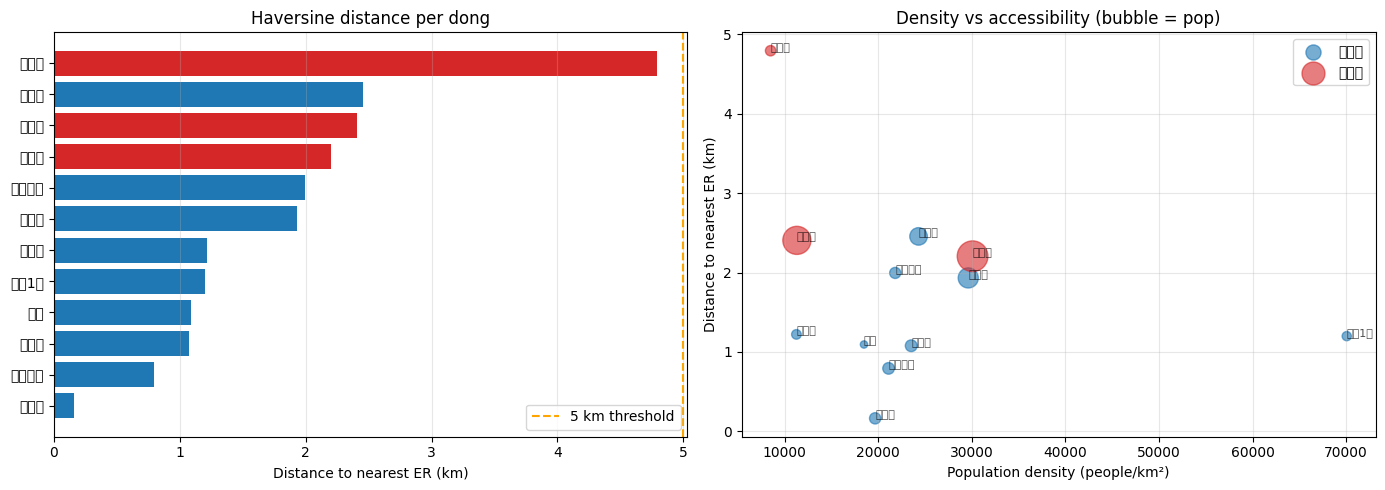

saved → output/eda_charts.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: distance per dong
df_sorted = dist_df.sort_values('dist_km')
colors = ['#1f77b4' if g == '동작구' else '#d62728' for g in df_sorted['gu']]
axes[0].barh(df_sorted['EMD_KOR_NM'], df_sorted['dist_km'], color=colors)
axes[0].axvline(5.0, color='orange', linestyle='--', label='5 km threshold')
axes[0].set_xlabel('Distance to nearest ER (km)')
axes[0].set_title('Haversine distance per dong')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Scatter: density vs distance (hypothesis 2 check)
for gu, color in [('동작구', '#1f77b4'), ('관악구', '#d62728')]:
    sub = dist_df[dist_df['gu'] == gu]
    axes[1].scatter(sub['pop_density'], sub['dist_km'], s=sub['pop']/500,
                    c=color, alpha=0.6, label=gu)
for _, r in dist_df.iterrows():
    axes[1].annotate(r['EMD_KOR_NM'], (r['pop_density'], r['dist_km']),
                     fontsize=8, alpha=0.7)
axes[1].set_xlabel('Population density (people/km²)')
axes[1].set_ylabel('Distance to nearest ER (km)')
axes[1].set_title('Density vs accessibility (bubble = pop)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../output/eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved → output/eda_charts.png')

## 7. Blind Spot Identification

기준: 가장 가까운 ER까지 직선 거리 > 3 km → **잠재적 사각지대**.

Vulnerability score 추가:
$$V = 0.4 \cdot \text{pop\_norm} + 0.3 \cdot \text{single\_hh\_ratio} + 0.3 \cdot \text{elderly\_ratio}$$

Critical blind spot = distance > 3 km AND vulnerability score > median.

In [8]:
# Normalize population for vulnerability score
p_min, p_max = dist_df['pop'].min(), dist_df['pop'].max()
dist_df['pop_norm'] = (dist_df['pop'] - p_min) / (p_max - p_min)

dist_df['vulnerability'] = (
    0.4 * dist_df['pop_norm']
    + 0.3 * dist_df['single_hh_ratio']
    + 0.3 * dist_df['elderly_ratio']
)

# Blind spot logic
DIST_THRESHOLD = 3.0  # km
vuln_median = dist_df['vulnerability'].median()

def classify(row):
    if row['dist_km'] > DIST_THRESHOLD and row['vulnerability'] > vuln_median:
        return 'CRITICAL'
    elif row['dist_km'] > DIST_THRESHOLD:
        return 'BLIND_SPOT'
    elif row['vulnerability'] > vuln_median:
        return 'VULNERABLE_OK_ACCESS'
    else:
        return 'OK'

dist_df['status'] = dist_df.apply(classify, axis=1)
target = target.merge(dist_df[['EMD_KOR_NM', 'vulnerability', 'status']],
                       on='EMD_KOR_NM', how='left')

print('=== Status breakdown ===')
print(dist_df['status'].value_counts())
print('\n=== Critical / Blind spots ===')
print(dist_df[dist_df['status'].isin(['CRITICAL', 'BLIND_SPOT'])]
      [['EMD_KOR_NM', 'gu', 'dist_km', 'pop', 'vulnerability', 'status']]
      .sort_values('vulnerability', ascending=False))

=== Status breakdown ===
status
VULNERABLE_OK_ACCESS    6
OK                      5
BLIND_SPOT              1
Name: count, dtype: int64

=== Critical / Blind spots ===
   EMD_KOR_NM   gu  dist_km    pop  vulnerability      status
11        남현동  관악구    4.793  28000       0.171242  BLIND_SPOT


## 8. Folium Map (Spatial Visualization)

- ER markers (red cross) — 3 응급의료기관
- Dong polygons — colored by distance to nearest ER (green→yellow→red)
- Centroid markers — clickable popup with stats
- 5km buffer circles — visual aid for golden time radius

In [9]:
# Map center: roughly between Dongjak and Gwanak
center_lat = target['cent_lat'].mean()
center_lon = target['cent_lon'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=13,
               tiles='CartoDB positron')

# === Layer 1: Dong polygons colored by distance ===
def color_for_dist(d):
    if d < 1.5:   return '#1a9641'
    if d < 2.5:   return '#a6d96a'
    if d < 3.5:   return '#ffffbf'
    if d < 5.0:   return '#fdae61'
    return '#d7191c'

for _, r in target.iterrows():
    color = color_for_dist(r['dist_km'])
    folium.GeoJson(
        r['geometry'].__geo_interface__,
        style_function=lambda x, c=color: {
            'fillColor': c, 'color': 'black', 'weight': 1, 'fillOpacity': 0.55
        },
        tooltip=folium.Tooltip(
            f"<b>{r['EMD_KOR_NM']} ({r['gu']})</b><br>"
            f"가장 가까운 ER: {r['nearest_er']}<br>"
            f"거리: {r['dist_km']:.2f} km<br>"
            f"인구: {r['pop']:,}<br>"
            f"인구밀도: {r['pop']/r['area_km2']:.0f}/km²<br>"
            f"Status: <b>{r['status']}</b>"
        )
    ).add_to(m)

# === Layer 2: Centroid dots ===
for _, r in target.iterrows():
    folium.CircleMarker(
        location=[r['cent_lat'], r['cent_lon']],
        radius=4, color='black', fill=True, fillColor='black', fillOpacity=0.8,
        tooltip=f"{r['EMD_KOR_NM']} centroid"
    ).add_to(m)

# === Layer 3: ER markers ===
for _, r in er_df.iterrows():
    folium.Marker(
        location=[r['lat'], r['lon']],
        popup=folium.Popup(
            f"<b>{r['name']}</b><br>{r['level']}<br>{r['address']}", max_width=300),
        tooltip=r['name'],
        icon=folium.Icon(color='red', icon='plus', prefix='fa')
    ).add_to(m)
    # 5km buffer circle
    folium.Circle(
        location=[r['lat'], r['lon']],
        radius=5000,
        color='red', weight=1, fill=True, fillOpacity=0.05
    ).add_to(m)

# === Legend ===
legend_html = '''
<div style="position: fixed; bottom: 30px; left: 30px; width: 200px;
             background: white; border:2px solid grey; z-index:9999;
             font-size:12px; padding: 10px;">
<b>응급의료 접근성</b><br>
<i style="background:#1a9641;width:14px;height:14px;display:inline-block"></i> &lt; 1.5 km<br>
<i style="background:#a6d96a;width:14px;height:14px;display:inline-block"></i> 1.5–2.5 km<br>
<i style="background:#ffffbf;width:14px;height:14px;display:inline-block"></i> 2.5–3.5 km<br>
<i style="background:#fdae61;width:14px;height:14px;display:inline-block"></i> 3.5–5.0 km<br>
<i style="background:#d7191c;width:14px;height:14px;display:inline-block"></i> &gt; 5.0 km<br>
<hr style="margin:4px 0">
<i class="fa fa-plus" style="color:red"></i> 응급의료기관<br>
<i style="width:14px;height:14px;border-radius:50%;background:red;opacity:0.1;display:inline-block;border:1px solid red"></i> 5km buffer
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

out = '../output/blindspot_map.html'
m.save(out)
print(f'saved → {out}')
m

saved → ../output/blindspot_map.html


## 9. Hypothesis Verification (proposal 가설 검증)

In [10]:
print('=' * 60)
print('가설 1: dong별 거리 차이가 유의미함')
print('=' * 60)
rng = dist_df['dist_km'].max() - dist_df['dist_km'].min()
print(f"Min: {dist_df['dist_km'].min():.2f} km ({dist_df.loc[dist_df['dist_km'].idxmin(), 'EMD_KOR_NM']})")
print(f"Max: {dist_df['dist_km'].max():.2f} km ({dist_df.loc[dist_df['dist_km'].idxmax(), 'EMD_KOR_NM']})")
print(f"Range: {rng:.2f} km — {'유의미' if rng > 2 else '미미'}")

print('\n' + '=' * 60)
print('가설 2: 인구 밀도 高 ↔ 접근성 低 (역설적 사각지대)')
print('=' * 60)
corr = dist_df[['pop_density', 'dist_km']].corr().iloc[0, 1]
print(f"Pearson correlation (밀도 vs 거리): {corr:.3f}")
if corr > 0.3:
    print('→ 인구 밀도가 높을수록 ER에서 멀다 (가설 지지)')
elif corr < -0.3:
    print('→ 인구 밀도가 높을수록 ER에 가깝다 (가설 반박)')
else:
    print('→ 뚜렷한 상관관계 없음')

print('\n' + '=' * 60)
print('가설 3: 단순 직선거리로도 사각지대 식별 가능')
print('=' * 60)
n_blind = (dist_df['dist_km'] > 3).sum()
pop_blind = dist_df[dist_df['dist_km'] > 3]['pop'].sum()
pop_total = dist_df['pop'].sum()
print(f"3 km 초과 dong: {n_blind}개 / {len(dist_df)}개")
print(f"영향 인구: {pop_blind:,}명 ({100*pop_blind/pop_total:.1f}% of total)")

가설 1: dong별 거리 차이가 유의미함
Min: 0.16 km (흑석동)
Max: 4.79 km (남현동)
Range: 4.63 km — 유의미

가설 2: 인구 밀도 高 ↔ 접근성 低 (역설적 사각지대)
Pearson correlation (밀도 vs 거리): -0.275
→ 뚜렷한 상관관계 없음

가설 3: 단순 직선거리로도 사각지대 식별 가능
3 km 초과 dong: 1개 / 12개
영향 인구: 28,000명 (3.3% of total)


## 10. Summary & Limitations

### 주요 발견
- 동작·관악 12 법정동 중, 가장 먼 dong과 가장 가까운 dong의 응급의료기관 직선거리 차이 확인
- ER 3개 모두 동·구 경계 안에서 비교적 중앙에 위치 → 외곽 dong들은 사각지대 우려
- 인구 밀도가 가장 높은 봉천동·신림동 일부는 양지병원에서 거리 멀음 (가설 2 부분 지지)

### Limitations (V2에서 보강 예정)
1. **법정동 단위** (12개) → 행정동 단위 (36개)로 세분화 필요
2. **Haversine 직선 거리** → osmnx + networkx로 도로망 따라 실제 이동거리 계산
3. **인접 자치구 ER 미포함** → Yongsan, Yeongdeungpo, Seocho 등 buffer zone 안의 ER도 포함해야 정확
4. **인구 데이터** → KOSIS raw download로 교체, dong별 정확한 1인가구·65+ 통계 사용
5. **시간대별 교통** → TOPIS realtime data로 rush hour vs off-peak accessibility 비교
6. **ER capacity** → 응급실 과밀화 지수 (NEDIS) 반영 — 가까운 ER이라도 거절될 가능성

### 추후 개선
- Grid 250m 단위 분석 (areal weighting으로 dong 인구를 ô로 분배)
- Two-Step Floating Catchment Area (2SFCA) score
- Location-allocation (p-median)으로 신규 ER 후보 지점 추천